# IY025: SVM on Median-Split Binary Labels (IY019 data, IY010-style)

How well can an SVM classify individual trajectories as "high" vs "low" for a given summary statistic, and how much of that signal survives time-axis shuffling?

## Labelling approach

Labels are **manually assigned by median split**: for each variation dataset, the target statistic (μ, CV, or t_ac) is computed for every trajectory, and trajectories are labelled 1 (above population median) or 0 (below). This is an analyst-imposed binary threshold — unlike the pairwise/contrastive labels in `IY025_svm_pairwise_variation_IY011_IY014.ipynb`, it treats each trajectory independently and requires choosing a labelling criterion.

Pipeline (mirrors `transformer_simulation_7_varying_1_stat_analysis.ipynb` from IY010):
1. Load raw trajectory CSVs from IY019 (Sobol-sampled parameter space)
2. `standardise_time_series` — per-trajectory z-score
3. `add_binary_labels` — median split on the target stat column
4. `load_and_split_data` — 80/20 train/test
5. SVM (RBF) on: **original**, **global shuffle**, **per-sample shuffle**

## Permutation controls

- **Global shuffle:** all time points pooled across trajectories then redistributed — destroys both temporal and per-trajectory structure
- **Per-sample shuffle:** each trajectory's time axis shuffled independently — destroys temporal autocorrelation while preserving each trajectory's marginal distribution (mean and variance unchanged)

If per-sample shuffling does not reduce accuracy, the SVM signal comes from static distributional features (e.g. variance differences), not from temporal structure.


In [1]:
import sys, os
sys.path.insert(0, '../../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from utils.data_processing import add_binary_labels
from utils.standardise_time_series import standardise_time_series
from utils.shuffle_time_series import shuffle_time_series
from dataloaders.core import load_and_split_data
from classifiers.svm_classifier import svm_classifier

%load_ext autoreload
%autoreload 2

In [2]:
IY019_ROOT = Path('../EXP-26-IY019')
MAX_SAMPLES = 1024  # per dataset (not per label); kept low because file I/O ~37ms/file

EXPERIMENT_CONFIGS = {
    'mu variation': [
        {'label': 'mu',   'label_col': 'mu_target',  'color': 'steelblue'},
    ],
    'cv variation': [
        {'label': 'cv',   'label_col': 'cv_target',   'color': 'seagreen'},
    ],
    't_ac variation': [
        {'label': 't_ac', 'label_col': 't_ac_target', 'color': 'firebrick'},
    ],
}

DATASET_PATHS = {
    'mu variation':           (IY019_ROOT / 'data_mu_variation',  'IY019_simulation_mu_parameters_sobol.csv'),
    'cv variation':           (IY019_ROOT / 'data_cv_variation',  'IY019_simulation_cv_parameters_sobol.csv'),
    't_ac variation':         (IY019_ROOT / 'data_t_ac_variation','IY019_simulation_t_ac_parameters_sobol.csv'),
}

In [3]:
_dataset_cache = {}  # ds_label -> (results_df, data_frames_list)

def _load_dataset(ds_label):
    """Load and cache raw trajectory DataFrames for a dataset (shared across label sub-conditions)."""
    if ds_label in _dataset_cache:
        return _dataset_cache[ds_label]

    data_dir, csv_name = DATASET_PATHS[ds_label]
    results = pd.read_csv(data_dir / csv_name)
    results = results[
        (results['success'] == True) &
        results['error_message'].isna() &
        (results['mean_rel_error_pct'] < 10) &
        (results['cv_rel_error_pct']   < 10) &
        (results['t_ac_rel_error_pct'] < 10)
    ].reset_index(drop=True)

    if len(results) > MAX_SAMPLES:
        results = results.sample(MAX_SAMPLES, random_state=42).reset_index(drop=True)

    print(f"    Loading {len(results)} trajectory files from {data_dir.name}...")
    data_frames = [
        pd.read_csv(data_dir / fname, nrows=1)
        for fname in results['trajectory_filename'].values
    ]
    _dataset_cache[ds_label] = (results, data_frames)
    return results, data_frames


def load_experiment(ds_label, cfg):
    """Standardise, binary-label, and split cached trajectory DataFrames."""
    results, data_frames = _load_dataset(ds_label)
    labelled = add_binary_labels(results, cfg['label_col'])
    labels = [
        labelled.loc[labelled['trajectory_filename'] == fname, 'label'].iloc[0]
        for fname in results['trajectory_filename'].values
    ]

    labelled_data = standardise_time_series(data_frames, labels=labels, prefix='t_')
    print(f"    N={len(labelled_data)}, NaN={labelled_data.isnull().sum().sum()}")

    tmp = Path('/tmp') / f"_iy025_{ds_label.replace(' ', '_')}_{cfg['label']}.csv"
    labelled_data.to_csv(tmp, index=False)
    X_tr, X_te, y_tr, y_te = load_and_split_data(tmp)
    os.remove(tmp)
    return labelled_data, X_tr, X_te, y_tr, y_te


def run_svm_with_strategies(labelled_data, X_tr, X_te, y_tr, y_te, tag=''):
    """Returns (orig_acc, global_acc, per_sample_acc)."""
    print('    [original]  ', end='')
    orig = svm_classifier(X_tr, X_te, y_tr, y_te)

    for strategy in ('global', 'per_sample'):
        df_shuf = shuffle_time_series(
            labelled_data.copy(), preserve_columns=['label'],
            random_state=42, strategy=strategy
        )
        tmp = Path('/tmp') / f'_iy025_shuf_{strategy}_{tag}.csv'
        df_shuf.to_csv(tmp, index=False)
        X_tr_s, X_te_s, y_tr_s, y_te_s = load_and_split_data(tmp)
        os.remove(tmp)
        print(f'    [{strategy}]  ', end='')
        acc = svm_classifier(X_tr_s, X_te_s, y_tr_s, y_te_s)
        if strategy == 'global':
            glob = acc
        else:
            pers = acc

    return orig, glob, pers

## Run

In [4]:
all_results = {}  # {dataset: {condition: (orig, global, per_sample)}}

for ds_label, cfgs in EXPERIMENT_CONFIGS.items():
    print(f'\n=== {ds_label} ===')
    all_results[ds_label] = {}
    for cfg in cfgs:
        print(f'\n  [{cfg["label"]}]')
        labelled_data, X_tr, X_te, y_tr, y_te = load_experiment(ds_label, cfg)
        orig, glob, pers = run_svm_with_strategies(
            labelled_data, X_tr, X_te, y_tr, y_te,
            tag=f"{ds_label.replace(' ', '_')}_{cfg['label']}"
        )
        all_results[ds_label][cfg['label']] = (orig, glob, pers)

print('\n\n=== Summary ===')
print(f'{"dataset":<26} {"condition":<8} {"original":>10} {"global":>10} {"per_sample":>12}')
print('-' * 68)
for ds_label, res in all_results.items():
    for cond, (orig, glob, pers) in res.items():
        print(f'{ds_label:<26} {cond:<8} {orig:>10.4f} {glob:>10.4f} {pers:>12.4f}')


=== mu variation ===

  [mu]
    Loading 1024 trajectory files from data_mu_variation...
    N=1024, NaN=0
    [original]  === SVM (RBF Kernel) Classification Accuracy: 0.98 ===
    [global]  === SVM (RBF Kernel) Classification Accuracy: 0.98 ===
    [per_sample]  === SVM (RBF Kernel) Classification Accuracy: 0.99 ===

=== cv variation ===

  [cv]
    Loading 1024 trajectory files from data_cv_variation...
    N=1024, NaN=0
    [original]  === SVM (RBF Kernel) Classification Accuracy: 0.98 ===
    [global]  === SVM (RBF Kernel) Classification Accuracy: 0.98 ===
    [per_sample]  === SVM (RBF Kernel) Classification Accuracy: 0.98 ===

=== t_ac variation ===

  [t_ac]
    Loading 1024 trajectory files from data_t_ac_variation...
    N=1024, NaN=0
    [original]  === SVM (RBF Kernel) Classification Accuracy: 0.76 ===
    [global]  === SVM (RBF Kernel) Classification Accuracy: 0.76 ===
    [per_sample]  === SVM (RBF Kernel) Classification Accuracy: 0.53 ===


=== Summary ===
dataset      

## Plot

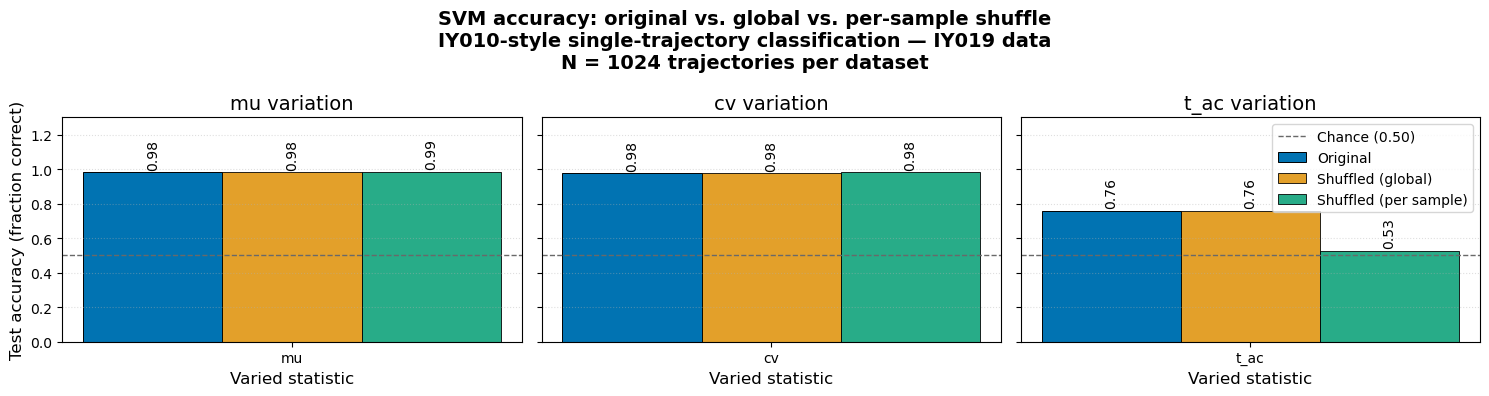

In [5]:
import seaborn as sns

plt.rcParams.update({
    "font.family":     "sans-serif",
    "axes.labelsize":  12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.titlesize":  14,
})

palette = sns.color_palette("colorblind")
width = 0.25

n_panels = len(EXPERIMENT_CONFIGS)
fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 4), sharey=True)

for ax, (ds_label, cfgs) in zip(axes, EXPERIMENT_CONFIGS.items()):
    res   = all_results[ds_label]
    conds = [c['label'] for c in cfgs]
    x     = np.arange(len(conds))

    b1 = ax.bar(x - width, [res[c][0] for c in conds], width,
                label='Original',              color=palette[0],
                edgecolor='black', linewidth=0.7)
    b2 = ax.bar(x,          [res[c][1] for c in conds], width,
                label='Shuffled (global)',     color=palette[1],
                edgecolor='black', linewidth=0.7, alpha=0.85)
    b3 = ax.bar(x + width,  [res[c][2] for c in conds], width,
                label='Shuffled (per sample)', color=palette[2],
                edgecolor='black', linewidth=0.7, alpha=0.85)

    for bars in (b1, b2, b3):
        ax.bar_label(bars, fmt='%.2g', padding=2, rotation=90)

    ax.axhline(0.5, color='dimgrey', linestyle='--', linewidth=1,
               label='Chance (0.50)')
    ax.set_xticks(x)
    ax.set_xticklabels(conds)
    ax.set_xlabel('Varied statistic')
    ax.set_title(ds_label)
    ax.set_ylim(0, 1.3)
    ax.grid(axis='y', linestyle=':', alpha=0.4)

axes[0].set_ylabel('Test accuracy (fraction correct)')
axes[-1].legend(loc='upper right')
fig.suptitle(
    'SVM accuracy: original vs. global vs. per-sample shuffle\n'
    'IY010-style single-trajectory classification — IY019 data\n'
    f'N = {MAX_SAMPLES} trajectories per dataset',
    fontsize=14, weight='bold'
)
plt.tight_layout()
plt.savefig('IY025_svm_permutation_test.png', dpi=150, bbox_inches='tight')
plt.show()
